# Machine C — Exploratory Data Analysis

**Dataset:** `ml/data/raw_data/sensordata 1.csv`  
**Description:** 3-axis vibration + temperature, collected in discrete sessions at ~500ms intervals.

## Columns
| Column | Type | Description |
|--------|------|-------------|
| `SessionId` | int | Discrete recording session identifier |
| `VibrationX` | float | X-axis vibration (g) |
| `VibrationY` | float | Y-axis vibration (g) |
| `VibrationZ` | float | Z-axis vibration (g) |
| `Temperature` | float | Sensor temperature (°C) |
| `TimeCollected` | str → datetime | Timestamp of reading |
| `Label` | str | Machine state: `low`, `medium`, `high` |

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

DATA_PATH = '../../data/raw_data/sensordata 1.csv'
FEATURES = ['VibrationX', 'VibrationY', 'VibrationZ', 'Temperature']
LABEL_ORDER = ['low', 'medium', 'high']
LABEL_COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}

## 1. Load & Basic Overview

In [67]:
df = pd.read_csv(DATA_PATH)
df['TimeCollected'] = pd.to_datetime(df['TimeCollected'])
df = df.sort_values(['SessionId', 'TimeCollected']).reset_index(drop=True)

print(f'Shape          : {df.shape}')
print(f'Date range     : {df["TimeCollected"].min()} → {df["TimeCollected"].max()}')
print(f'Sessions       : {df["SessionId"].nunique()} unique')
print(f'Null values    :\n{df.isnull().sum()}')
df.head()

Shape          : (78049, 7)
Date range     : 2025-02-14 14:34:17.376000 → 2025-08-01 14:48:41.863000
Sessions       : 51 unique
Null values    :
SessionId        0
VibrationX       0
VibrationY       0
VibrationZ       0
Temperature      0
TimeCollected    0
Label            1
dtype: int64


,SessionId,VibrationX,VibrationY,VibrationZ,Temperature,TimeCollected,Label
0,5,0.228108,0.173349,0.187254,28.001379,2025-02-14 14:34:17.376,high
1,5,0.228108,0.173349,0.187254,27.999428,2025-02-14 14:34:17.876,high
2,5,0.222890,0.178260,0.177840,28.000237,2025-02-14 14:34:18.376,high
3,5,0.222890,0.178260,0.177840,27.999901,2025-02-14 14:34:18.876,high
4,5,0.222678,0.174074,0.170359,28.000038,2025-02-14 14:34:19.376,high


In [68]:
df.describe()

,SessionId,VibrationX,VibrationY,VibrationZ,Temperature,TimeCollected
count,78049.000000,78049.000000,78049.000000,78049.000000,78049.000000,78049
mean,39.710579,0.253914,0.282995,0.274701,33.427599,2025-04-30 13:33:10.856930
min,5.000000,0.092307,0.093939,0.097548,24.812496,2025-02-14 14:34:17.376000
25%,16.000000,0.132701,0.127597,0.137890,31.312813,2025-02-19 13:33:06.637000
50%,35.000000,0.149179,0.144858,0.153498,34.551769,2025-04-11 13:42:45.854000
75%,68.000000,0.243687,0.219728,0.262089,35.366966,2025-08-01 12:20:01.191000
max,78.000000,36.868095,52.567551,55.216488,39.659229,2025-08-01 14:48:41.863000
std,24.978033,0.889746,1.046038,1.041239,3.249536,NaN


## 2. Session Analysis

In [69]:
sess = df.groupby('SessionId').agg(
    start=('TimeCollected', 'min'),
    end=('TimeCollected', 'max'),
    n_rows=('TimeCollected', 'count'),
    label=('Label', lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
).reset_index()
sess['duration_s'] = (sess['end'] - sess['start']).dt.total_seconds()
sess['duration_min'] = sess['duration_s'] / 60
sess = sess.sort_values('start').reset_index(drop=True)

print('=== Rows per session ===')
print(sess['n_rows'].describe().round(1).to_string())
print('\n=== Session duration (minutes) ===')
print(sess['duration_min'].describe().round(2).to_string())

=== Rows per session ===
count       51.0
mean      1530.4
std       2982.7
min        240.0
25%        241.0
50%        480.0
75%       1028.0
max      19039.0

=== Session duration (minutes) ===
count    51.00
mean     10.13
std      15.20
min       1.99
25%       2.58
50%       4.10
75%       6.41
max      81.38


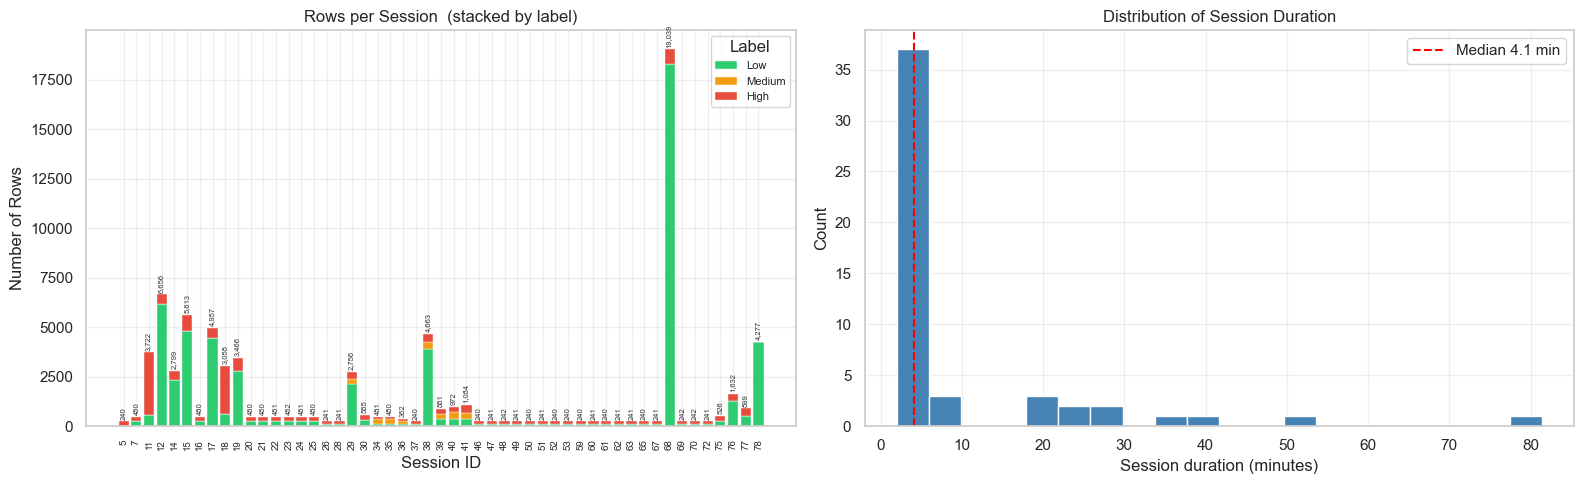

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rows per Session — stacked bar so mixed-label sessions (e.g. session 68)
# are shown accurately instead of collapsing to a single majority color.
sess_label_counts = (
    df.groupby(['SessionId', 'Label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
# Align to sess order (sorted by start time)
sess_label_counts = sess_label_counts.reindex(sess['SessionId'])
x = range(len(sess_label_counts))

bottoms = np.zeros(len(sess_label_counts))
for label in LABEL_ORDER:
    vals = sess_label_counts[label].values
    axes[0].bar(x, vals, bottom=bottoms,
                color=LABEL_COLORS[label], label=label.capitalize(),
                edgecolor='white', linewidth=0.3)
    bottoms += vals

# Total row count on top of each bar
for i, total in enumerate(sess_label_counts.sum(axis=1)):
    axes[0].text(i, total + 80, f'{int(total):,}',
                 ha='center', va='bottom', fontsize=5.5, color='#333', rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels(sess_label_counts.index.astype(str), rotation=90, fontsize=7)
axes[0].set_xlabel('Session ID')
axes[0].set_ylabel('Number of Rows')
axes[0].set_title('Rows per Session  (stacked by label)')
axes[0].legend(title='Label', fontsize=8)

# Session duration distribution
axes[1].hist(sess['duration_min'], bins=20, color='steelblue', edgecolor='white')
med = sess['duration_min'].median()
axes[1].axvline(med, color='red', linestyle='--', label=f'Median {med:.1f} min')
axes[1].set_xlabel('Session duration (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Session Duration')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Time Gaps Between Sessions

In [71]:
sess['gap_to_next_s'] = (sess['start'].shift(-1) - sess['end']).dt.total_seconds()
sess['gap_to_next_h'] = sess['gap_to_next_s'] / 3600

gaps = sess['gap_to_next_h'].dropna()
print('=== Inter-session gap (hours) ===')
print(gaps.describe().round(2).to_string())
print(f'\nMin gap : {gaps.min()*60:.1f} min')
print(f'Median  : {gaps.median():.2f} h  ({gaps.median()*60:.0f} min)')
print(f'Max gap : {gaps.max():.1f} h  ({gaps.max()/24:.1f} days)')

=== Inter-session gap (hours) ===
count      50.00
mean       80.47
std       268.24
min         0.00
25%         0.09
50%         0.27
75%         0.38
max      1393.31

Min gap : 0.0 min
Median  : 0.27 h  (16 min)
Max gap : 1393.3 h  (58.1 days)


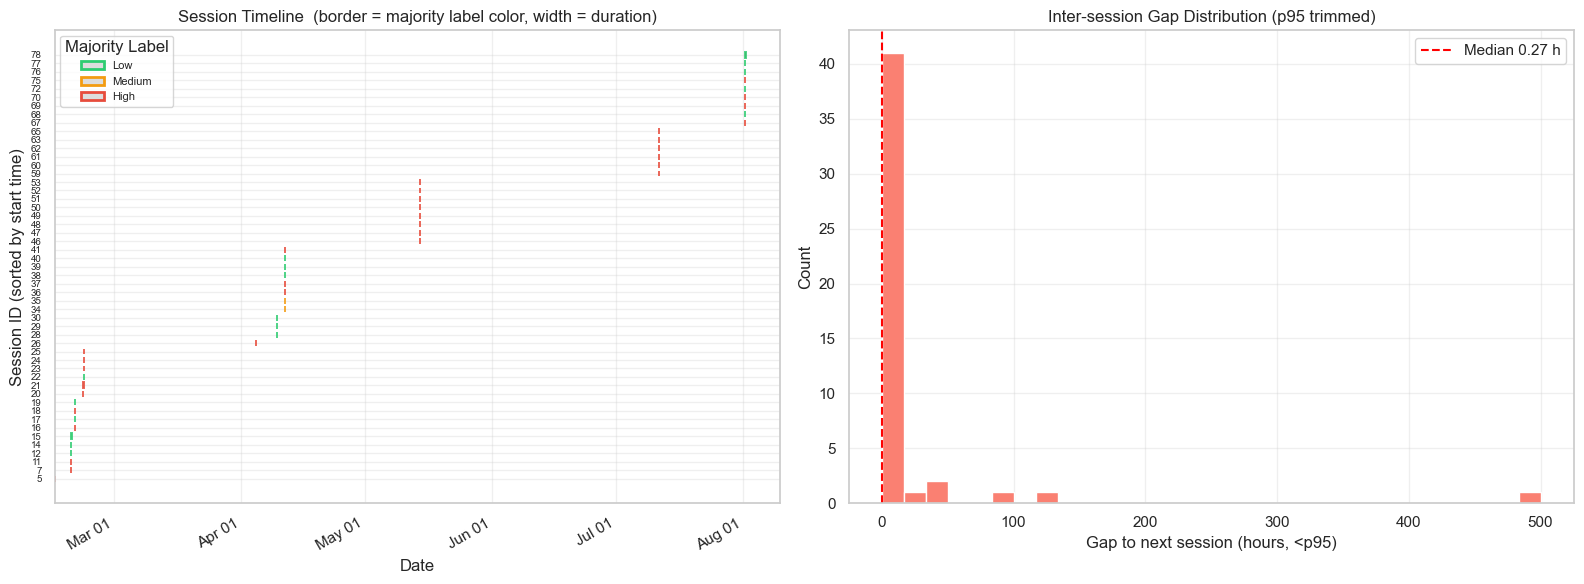

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Session Timeline — left in matplotlib date-number units (days), width must also be in days
n_sess = len(sess)
sess_bar_colors = [plt.cm.tab20(i % 20 / 20) for i in range(n_sess)]

for i, (_, row) in enumerate(sess.iterrows()):
    fill_color = sess_bar_colors[i]
    edge_color = LABEL_COLORS.get(row['label'], 'grey')
    axes[0].barh(i,
                 row['duration_s'] / 86400,           # width in days — same unit as date2num
                 left=mdates.date2num(row['start']),
                 color=fill_color, height=0.7, alpha=0.85,
                 edgecolor=edge_color, linewidth=1.4)

axes[0].set_yticks(range(n_sess))
axes[0].set_yticklabels(sess['SessionId'].astype(str), fontsize=7)
axes[0].set_ylabel('Session ID (sorted by start time)')

axes[0].xaxis_date()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].set_xlabel('Date')
axes[0].set_title('Session Timeline  (border = majority label color, width = duration)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

from matplotlib.patches import Patch
label_handles = [
    Patch(facecolor='#ddd', edgecolor=LABEL_COLORS[l], linewidth=2, label=l.capitalize())
    for l in LABEL_ORDER
]
axes[0].legend(handles=label_handles, title='Majority Label', fontsize=8)

# Gap distribution
gaps = sess['gap_to_next_h'].dropna()
axes[1].hist(gaps[gaps < gaps.quantile(0.95)], bins=30, color='salmon', edgecolor='white')
axes[1].axvline(gaps.median(), color='red', linestyle='--',
                label=f'Median {gaps.median():.2f} h')
axes[1].set_xlabel('Gap to next session (hours, <p95)')
axes[1].set_ylabel('Count')
axes[1].set_title('Inter-session Gap Distribution (p95 trimmed)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [73]:
# Show the full gap table
sess[['SessionId', 'start', 'end', 'duration_min', 'gap_to_next_h', 'n_rows', 'label']].round(2)

C:\Users\Admin\AppData\Local\Temp\ipykernel_27212\2653971991.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  sess[['SessionId', 'start', 'end', 'duration_min', 'gap_to_next_h', 'n_rows', 'label']].round(2)


,SessionId,start,end,duration_min,gap_to_next_h,n_rows,label
0,5,2025-02-14 14:34:17.376,2025-02-14 14:36:16.876,1.99,94.85,240,high
1,7,2025-02-18 13:27:21.659,2025-02-18 13:31:37.170,4.26,0.38,480,high
2,11,2025-02-18 13:54:19.204,2025-02-18 14:22:08.224,27.82,0.00,3722,high
3,12,2025-02-18 14:22:08.724,2025-02-18 15:15:05.276,52.94,0.08,6656,low
4,14,2025-02-18 15:20:04.280,2025-02-18 15:40:04.310,20.00,0.00,2799,low
5,15,2025-02-18 15:40:04.810,2025-02-18 16:08:03.336,27.98,21.42,5613,low
6,16,2025-02-19 13:33:05.637,2025-02-19 13:37:11.640,4.10,0.03,480,high
7,17,2025-02-19 13:38:53.143,2025-02-19 14:17:15.192,38.37,0.00,4957,low
8,18,2025-02-19 14:17:15.692,2025-02-19 14:39:23.707,22.13,0.00,3058,high
9,19,2025-02-19 14:39:24.207,2025-02-19 15:05:02.242,25.63,46.47,3466,low


## 4. Sampling Interval Within Sessions

Largest session: 68  (19039 rows)

=== Sampling interval (ms) ===
count    19038.00
mean       256.49
std        249.98
min          0.00
25%          0.00
50%        500.00
75%        500.00
max       1000.00


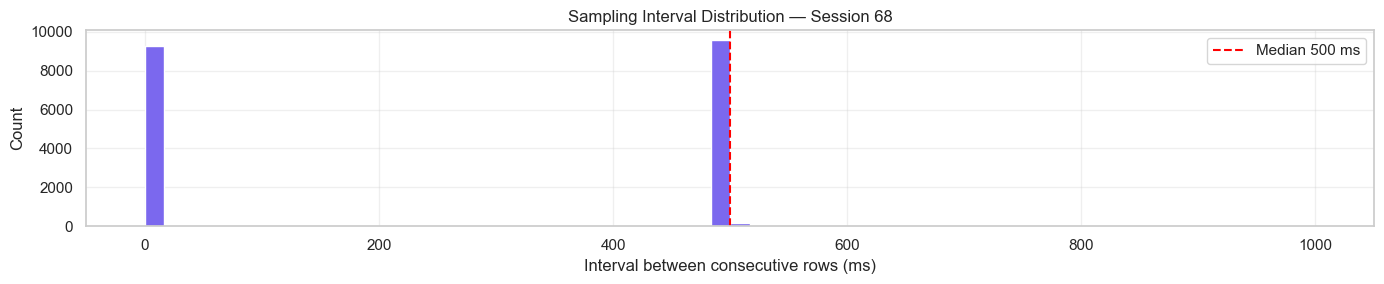

In [74]:
sample_sess = sess.sort_values('n_rows', ascending=False)['SessionId'].iloc[0]
sess_df = df[df['SessionId'] == sample_sess].copy()
intervals_ms = sess_df['TimeCollected'].diff().dt.total_seconds() * 1000

print(f'Largest session: {sample_sess}  ({len(sess_df)} rows)')
print('\n=== Sampling interval (ms) ===')
print(intervals_ms.dropna().describe().round(2).to_string())

plt.figure(figsize=(14, 3))
plt.hist(intervals_ms.dropna(), bins=60, color='mediumslateblue', edgecolor='white')
plt.axvline(intervals_ms.dropna().median(), color='red', linestyle='--',
            label=f'Median {intervals_ms.dropna().median():.0f} ms')
plt.xlabel('Interval between consecutive rows (ms)')
plt.ylabel('Count')
plt.title(f'Sampling Interval Distribution — Session {sample_sess}')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Label Distribution

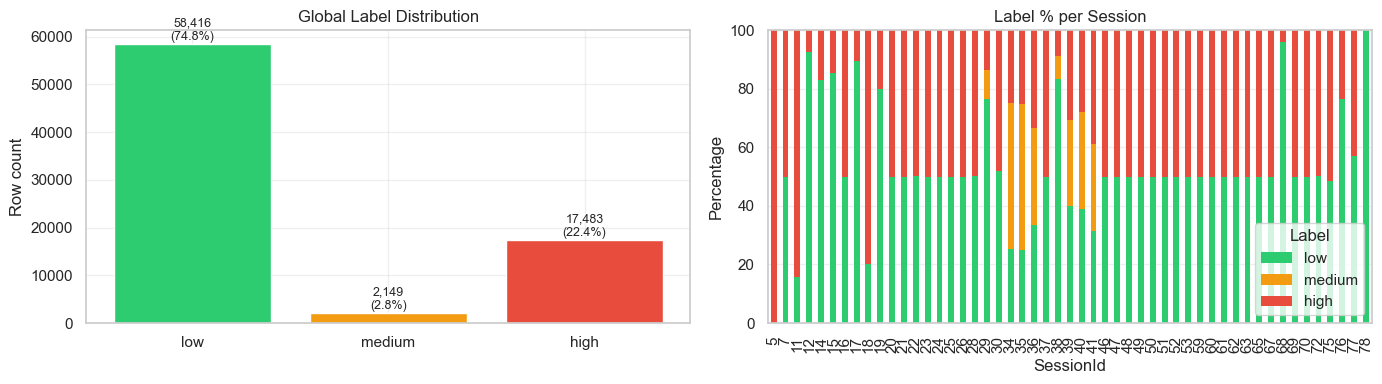


Note: heavy class imbalance — low >> high >> medium


In [75]:
label_counts = df['Label'].value_counts().reindex(LABEL_ORDER)
label_pct = label_counts / label_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(LABEL_ORDER, [label_counts[l] for l in LABEL_ORDER],
            color=[LABEL_COLORS[l] for l in LABEL_ORDER], edgecolor='white')
for i, (l, c) in enumerate(zip(LABEL_ORDER, [label_counts[l] for l in LABEL_ORDER])):
    axes[0].text(i, c + 200, f'{c:,}\n({label_pct[l]:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Global Label Distribution')
axes[0].set_ylabel('Row count')

# Label distribution per session (stacked bar)
sess_label = df.groupby(['SessionId', 'Label']).size().unstack(fill_value=0).reindex(columns=LABEL_ORDER, fill_value=0)
sess_label_pct = sess_label.div(sess_label.sum(axis=1), axis=0) * 100
sess_label_pct.plot(kind='bar', stacked=True, color=[LABEL_COLORS[l] for l in LABEL_ORDER],
                    ax=axes[1], edgecolor='none', legend=True)
axes[1].set_title('Label % per Session')
axes[1].set_xlabel('SessionId')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print('\nNote: heavy class imbalance — low >> high >> medium')

## 6. Feature Distributions

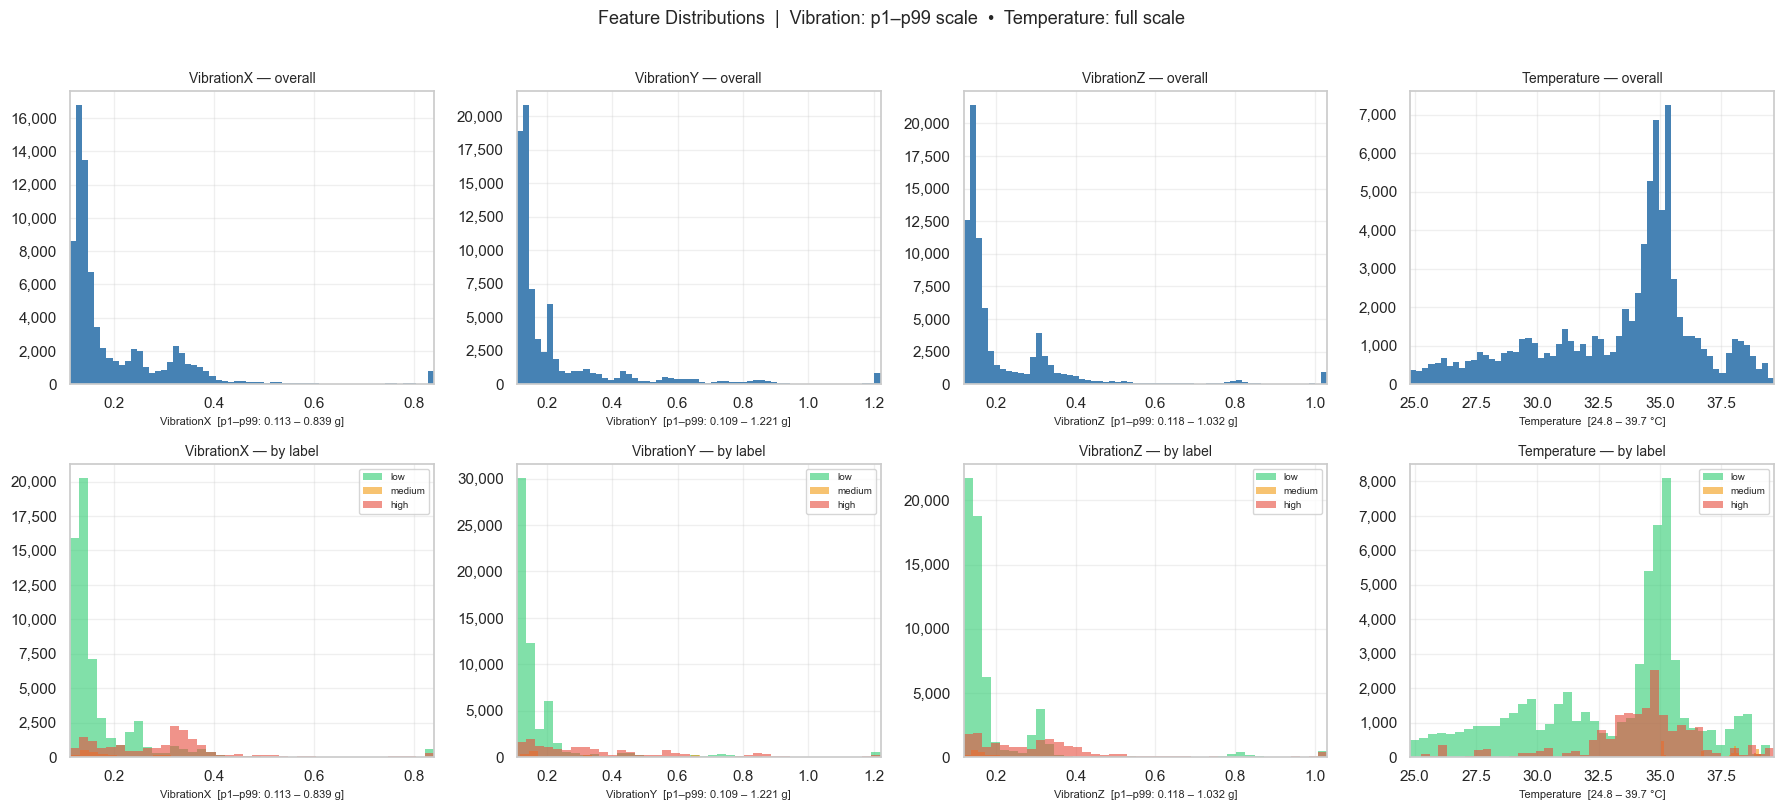

In [76]:
# Vibration axes (bulk values 0.1–0.5 g, outliers to 55 g) and Temperature (25–40 °C)
# sit on incompatible scales. Vibration histograms are clipped to p1–p99 so the
# main distribution is readable instead of being crushed by outliers.
vib_feats = ['VibrationX', 'VibrationY', 'VibrationZ']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col_i, feat in enumerate(FEATURES):
    data = df[feat].dropna()

    if feat in vib_feats:
        xlo, xhi = data.quantile(0.01), data.quantile(0.99)
        xlabel = f'{feat}  [p1–p99: {xlo:.3f} – {xhi:.3f} g]'
    else:
        xlo, xhi = data.min(), data.max()
        xlabel = f'{feat}  [{xlo:.1f} – {xhi:.1f} °C]'

    # Row 0: overall histogram
    axes[0, col_i].hist(data.clip(xlo, xhi), bins=60, color='steelblue', edgecolor='none')
    axes[0, col_i].set_xlim(xlo, xhi)
    axes[0, col_i].set_title(f'{feat} — overall', fontsize=10)
    axes[0, col_i].set_xlabel(xlabel, fontsize=8)
    axes[0, col_i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Row 1: by label
    for label in LABEL_ORDER:
        vals = df.loc[df['Label'] == label, feat].dropna().clip(xlo, xhi)
        axes[1, col_i].hist(vals, bins=40, alpha=0.6,
                             color=LABEL_COLORS[label], label=label, edgecolor='none')
    axes[1, col_i].set_xlim(xlo, xhi)
    axes[1, col_i].set_title(f'{feat} — by label', fontsize=10)
    axes[1, col_i].set_xlabel(xlabel, fontsize=8)
    axes[1, col_i].legend(fontsize=7)
    axes[1, col_i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle(
    'Feature Distributions  |  Vibration: p1–p99 scale  •  Temperature: full scale',
    y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27212\2354190404.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[col_i].boxplot(data_by_label, labels=LABEL_ORDER, patch_artist=True, notch=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27212\2354190404.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[col_i].boxplot(data_by_label, labels=LABEL_ORDER, patch_artist=True, notch=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27212\2354190404.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[col_i].boxplot(data_by_label, labels=LABEL_ORDER, patch_artist=True, notch=False)
C:\Users\A

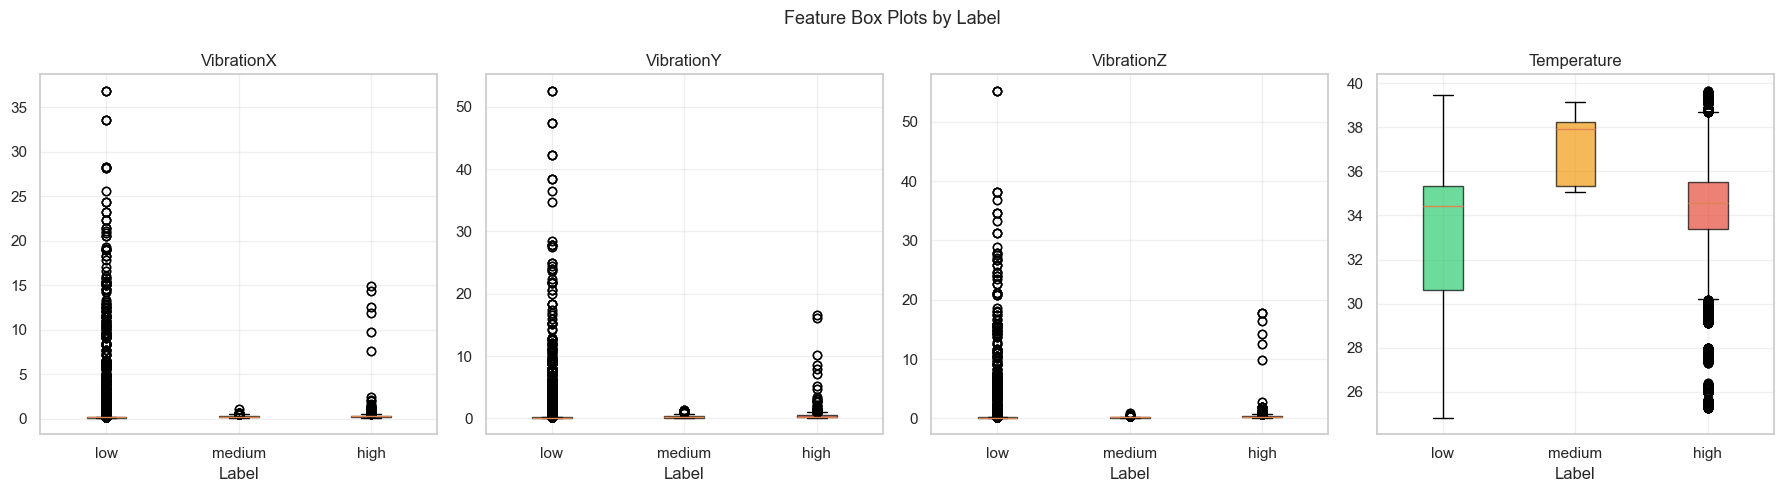

In [77]:
# Box plots per label
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for col_i, feat in enumerate(FEATURES):
    data_by_label = [df.loc[df['Label'] == l, feat].dropna() for l in LABEL_ORDER]
    bp = axes[col_i].boxplot(data_by_label, labels=LABEL_ORDER, patch_artist=True, notch=False)
    for patch, label in zip(bp['boxes'], LABEL_ORDER):
        patch.set_facecolor(LABEL_COLORS[label])
        patch.set_alpha(0.7)
    axes[col_i].set_title(feat)
    axes[col_i].set_xlabel('Label')

plt.suptitle('Feature Box Plots by Label', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature Fluctuation Over Time

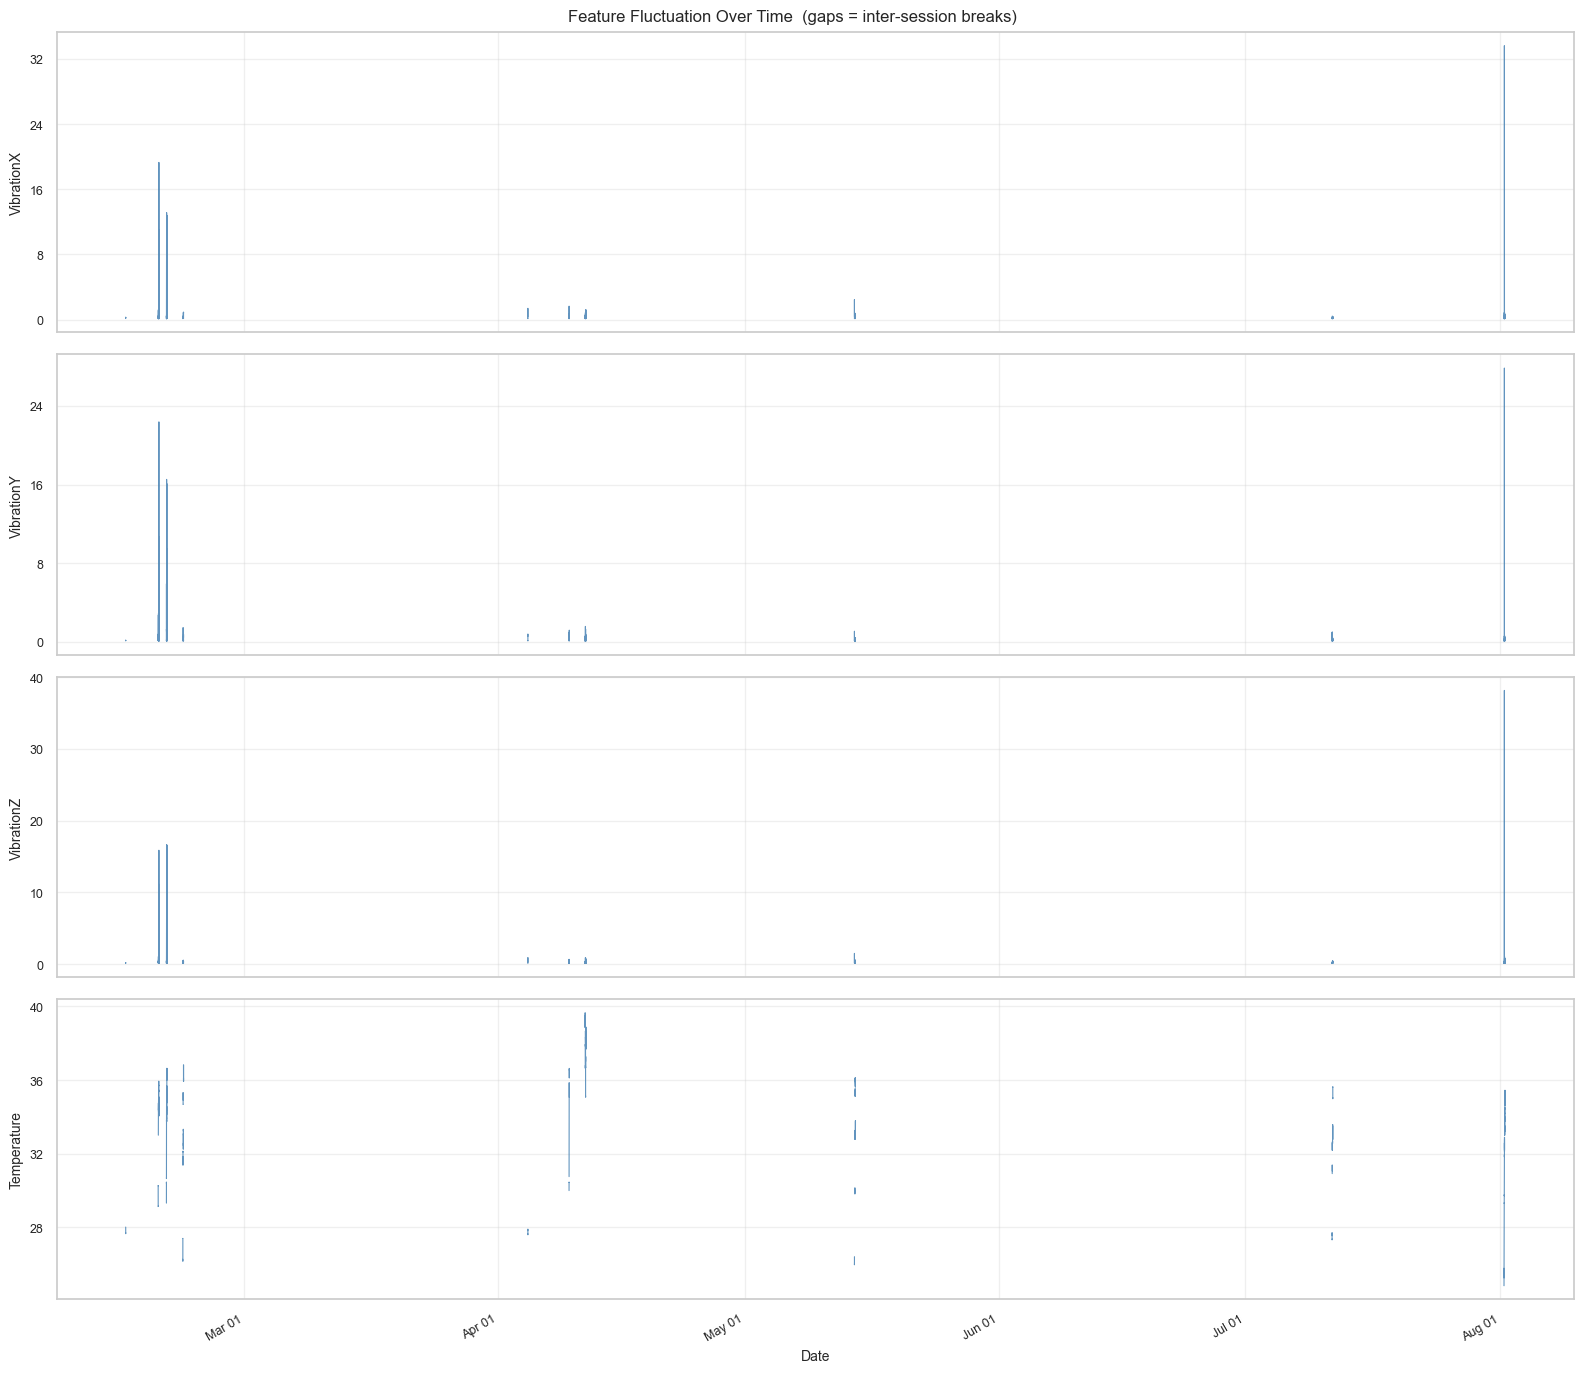

In [78]:
# Line chart with NaN breaks between sessions so inter-session gaps
# appear as white space rather than false connecting lines.
def build_gapped_df(source_df):
    parts = []
    for sid, grp in source_df.groupby('SessionId'):
        grp_s = grp.sort_values('TimeCollected')
        step  = max(1, len(grp_s) // 300)   # cap each session at ~300 pts
        parts.append(grp_s.iloc[::step][['TimeCollected'] + FEATURES])
        # NaN sentinel — forces a line break
        sentinel = {f: np.nan for f in FEATURES}
        sentinel['TimeCollected'] = grp_s['TimeCollected'].iloc[-1] + pd.Timedelta('1ms')
        parts.append(pd.DataFrame([sentinel]))
    return pd.concat(parts, ignore_index=True)

gapped = build_gapped_df(df)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for ax, feat in zip(axes, FEATURES):
    ax.plot(gapped['TimeCollected'], gapped[feat],
            linewidth=0.8, color='steelblue', alpha=0.85)
    ax.set_ylabel(feat, fontsize=10, labelpad=4)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune='both'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3g}'))
    ax.tick_params(axis='y', labelsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)
axes[-1].set_xlabel('Date', fontsize=10)

plt.suptitle('Feature Fluctuation Over Time  (gaps = inter-session breaks)', fontsize=12)
plt.tight_layout()
plt.show()

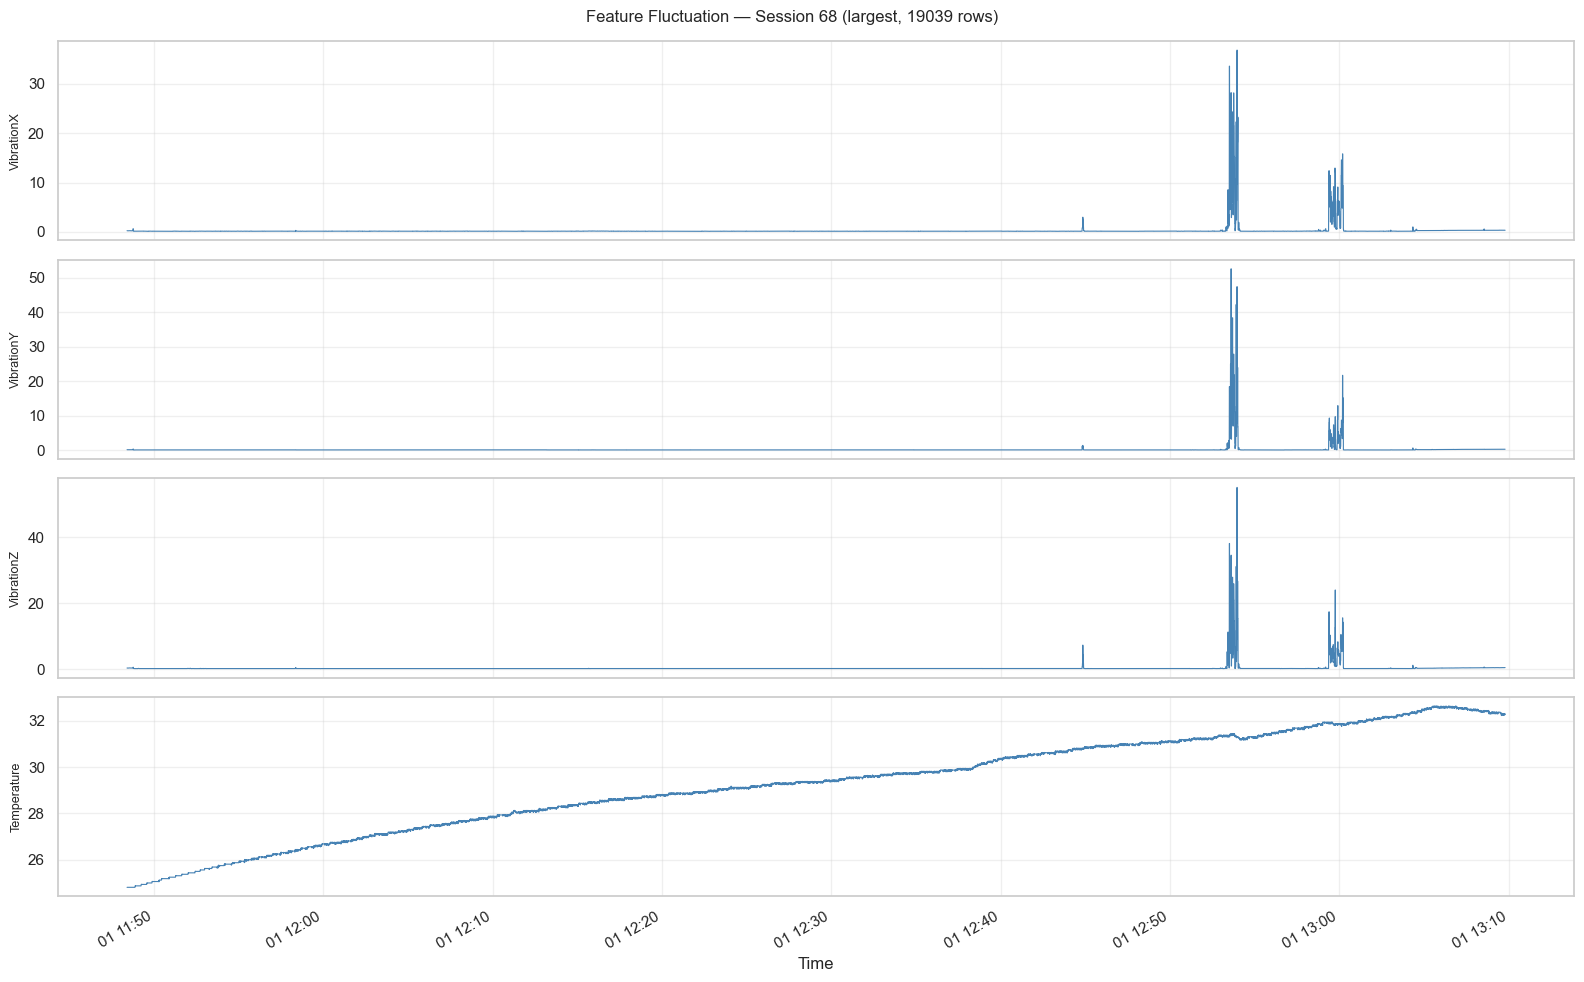

In [79]:
# Zoom: single representative session
focus_sess = sess.sort_values('n_rows', ascending=False)['SessionId'].iloc[0]
sess_data = df[df['SessionId'] == focus_sess].set_index('TimeCollected').sort_index()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
for ax, feat in zip(axes, FEATURES):
    ax.plot(sess_data.index, sess_data[feat], linewidth=0.8, color='steelblue')
    ax.set_ylabel(feat, fontsize=9)

axes[-1].set_xlabel('Time')
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.suptitle(f'Feature Fluctuation — Session {focus_sess} (largest, {len(sess_data)} rows)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

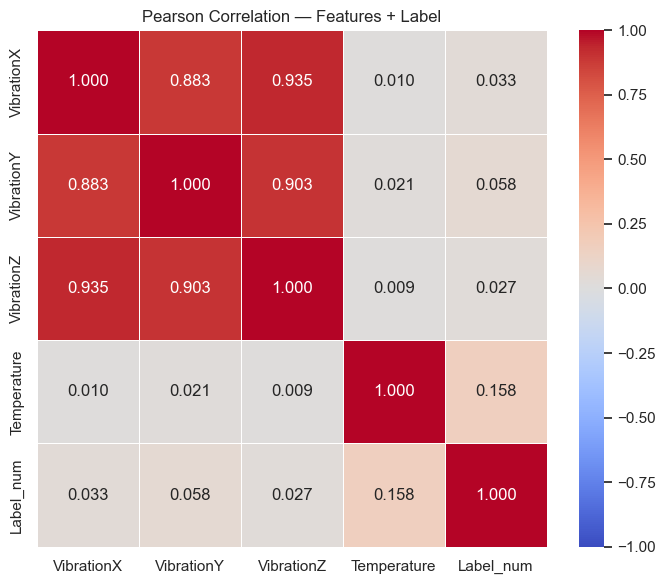


Correlation with Label (numeric):
Temperature    0.1584
VibrationY     0.0578
VibrationX     0.0331
VibrationZ     0.0274


In [80]:
# Numeric label for correlation
df['Label_num'] = df['Label'].map({'low': 0, 'medium': 1, 'high': 2})
corr_cols = FEATURES + ['Label_num']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=False,
            xticklabels=corr_cols, yticklabels=corr_cols)
ax.set_title('Pearson Correlation — Features + Label')
plt.tight_layout()
plt.show()

print('\nCorrelation with Label (numeric):')
print(corr['Label_num'].drop('Label_num').sort_values(key=abs, ascending=False).round(4).to_string())

In [81]:
# Per-session correlation (does within-session structure hold?)
per_sess_corr = []
for sid, grp in df.groupby('SessionId'):
    c = grp[FEATURES].corr()
    per_sess_corr.append({'SessionId': sid,
                          'VX_VY': c.loc['VibrationX', 'VibrationY'],
                          'VX_VZ': c.loc['VibrationX', 'VibrationZ'],
                          'VY_VZ': c.loc['VibrationY', 'VibrationZ'],
                          'VX_T' : c.loc['VibrationX', 'Temperature'],
                          'VY_T' : c.loc['VibrationY', 'Temperature'],
                          'VZ_T' : c.loc['VibrationZ', 'Temperature']})
per_sess_corr_df = pd.DataFrame(per_sess_corr)
print('Within-session correlations (mean across sessions):')
print(per_sess_corr_df.drop(columns='SessionId').mean().round(3).to_string())

Within-session correlations (mean across sessions):
VX_VY    0.847
VX_VZ    0.849
VY_VZ    0.844
VX_T     0.075
VY_T     0.031
VZ_T     0.043


## 9. Autocorrelation

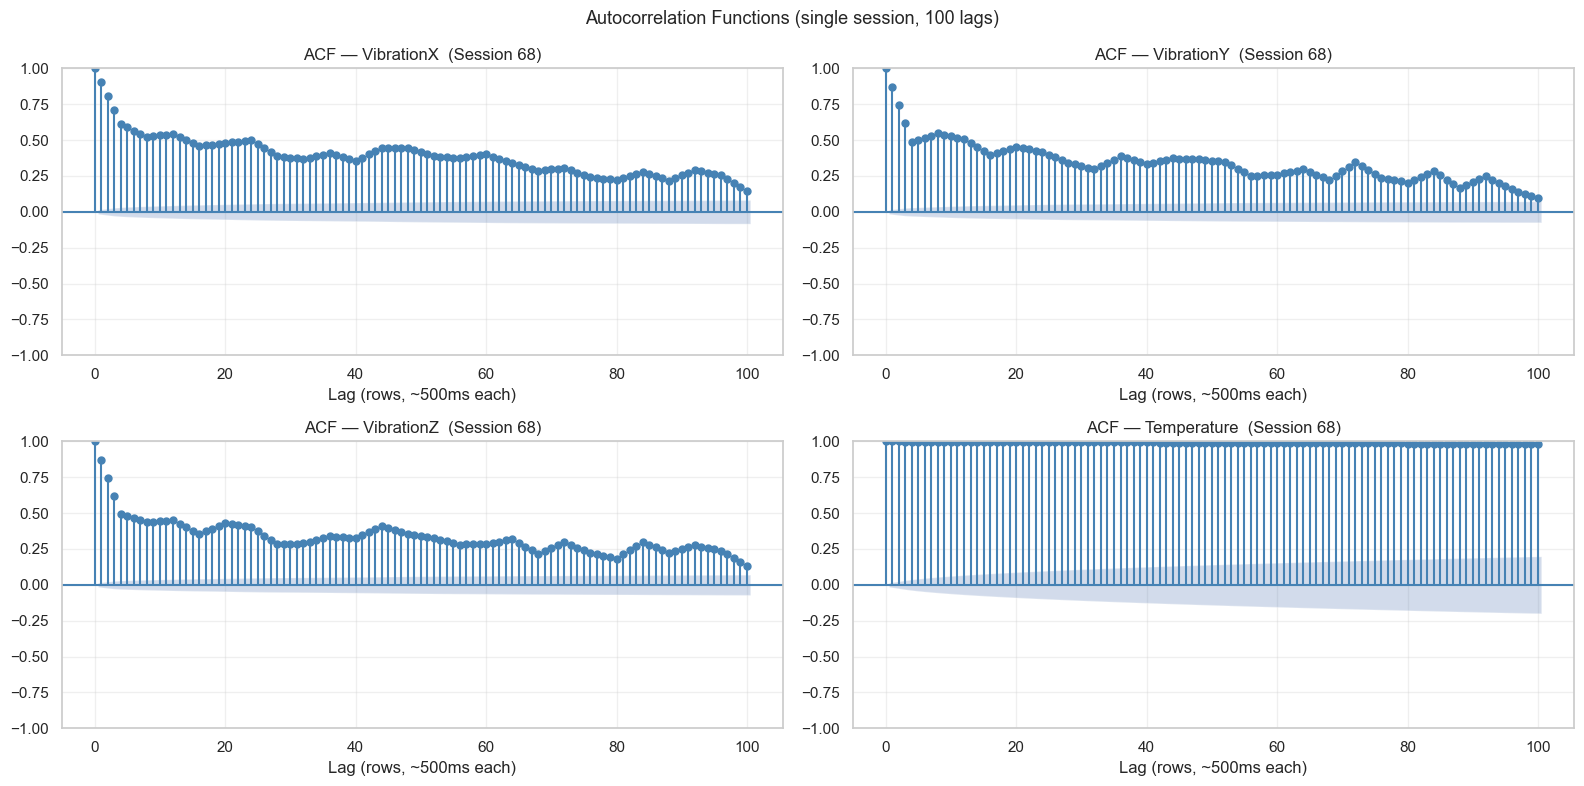

In [82]:
# ACF on the largest single session to avoid contamination from inter-session gaps
acf_sess = sess.sort_values('n_rows', ascending=False)['SessionId'].iloc[0]
acf_data = df[df['SessionId'] == acf_sess].sort_values('TimeCollected')

lags = 100
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), FEATURES):
    plot_acf(acf_data[feat].dropna(), lags=lags, ax=ax, alpha=0.05,
             color='steelblue', vlines_kwargs={'colors': 'steelblue'})
    ax.set_title(f'ACF — {feat}  (Session {acf_sess})')
    ax.set_xlabel('Lag (rows, ~500ms each)')

plt.suptitle('Autocorrelation Functions (single session, 100 lags)', fontsize=13)
plt.tight_layout()
plt.show()

In [83]:
# Manual lag-N autocorrelations for quick numeric summary
print('Lag autocorrelations within largest session:')
print(f'{"Feature":<14}', end='')
for lag in [1, 5, 10, 20, 50, 100]:
    print(f'lag={lag:<4}', end='')
print()
for feat in FEATURES:
    print(f'{feat:<14}', end='')
    s = acf_data[feat].dropna().reset_index(drop=True)
    for lag in [1, 5, 10, 20, 50, 100]:
        ac = s.autocorr(lag=lag)
        print(f'{ac:<8.3f}', end='')
    print()

Lag autocorrelations within largest session:
Feature       lag=1   lag=5   lag=10  lag=20  lag=50  lag=100 
VibrationX    0.903   0.590   0.532   0.481   0.419   0.145   
VibrationY    0.872   0.503   0.527   0.452   0.358   0.094   
VibrationZ    0.873   0.478   0.442   0.428   0.341   0.131   
Temperature   1.000   1.000   1.000   1.000   1.000   1.000   


## 10. Session-Level Feature Statistics

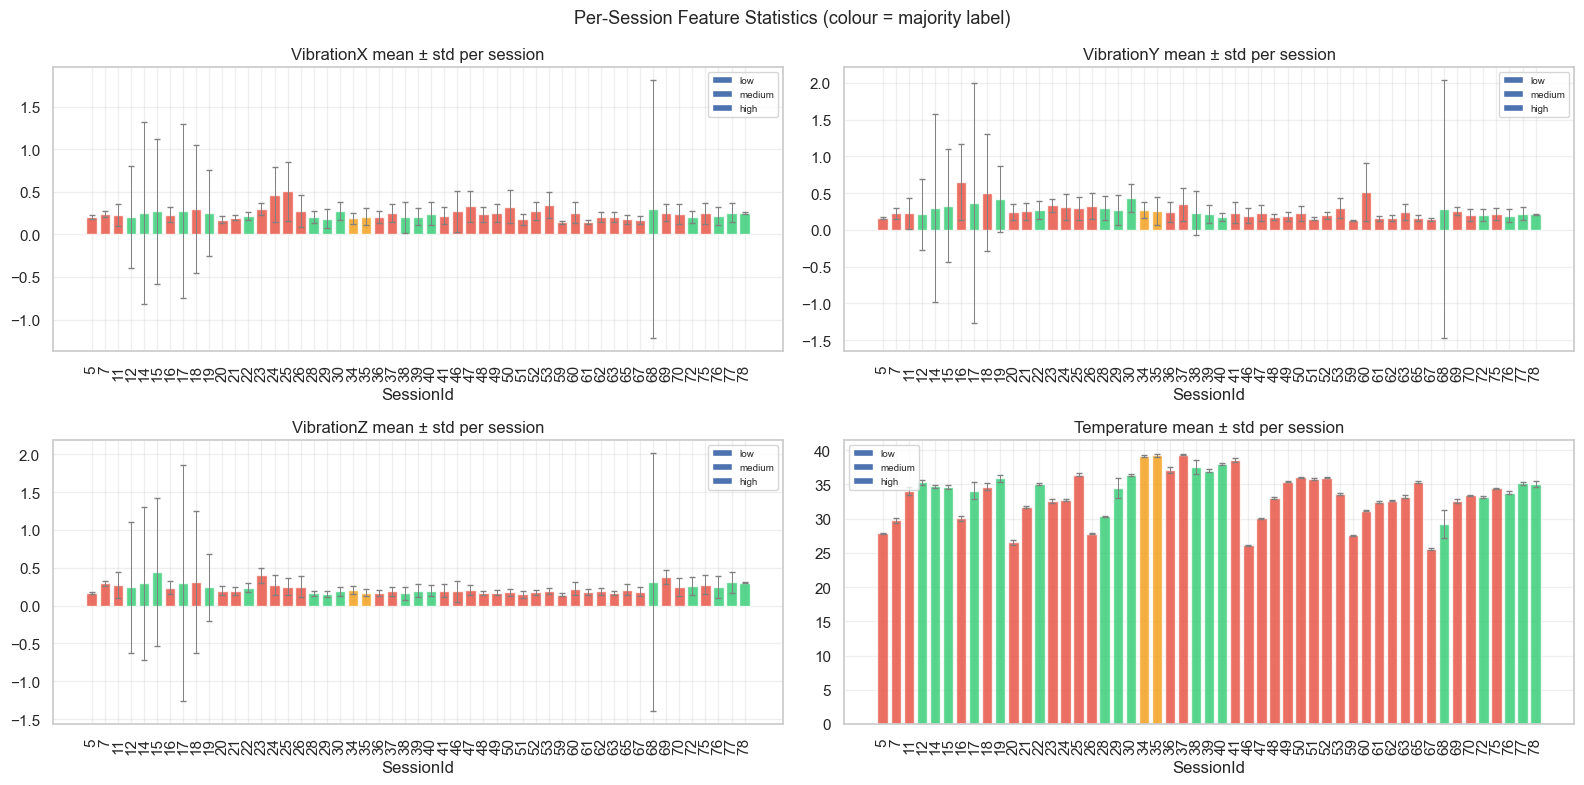

In [84]:
sess_stats = df.groupby('SessionId')[FEATURES].agg(['mean', 'std', 'min', 'max'])
sess_stats.columns = ['_'.join(c) for c in sess_stats.columns]
sess_stats = sess_stats.join(sess[['SessionId', 'duration_min', 'n_rows', 'label']].set_index('SessionId'))

# Mean vibration axes per session
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), FEATURES):
    colors = [LABEL_COLORS.get(l, 'grey') for l in sess_stats['label']]
    ax.bar(sess_stats.index.astype(str), sess_stats[f'{feat}_mean'],
           yerr=sess_stats[f'{feat}_std'], color=colors, alpha=0.8,
           ecolor='grey', capsize=2, error_kw={'linewidth': 0.7})
    ax.set_title(f'{feat} mean ± std per session')
    ax.set_xlabel('SessionId')
    ax.tick_params(axis='x', rotation=90)
    for label, color in LABEL_COLORS.items():
        ax.bar([], [], color=color, label=label, alpha=0.8)
    ax.legend(fontsize=7)

plt.suptitle('Per-Session Feature Statistics (colour = majority label)', fontsize=13)
plt.tight_layout()
plt.show()

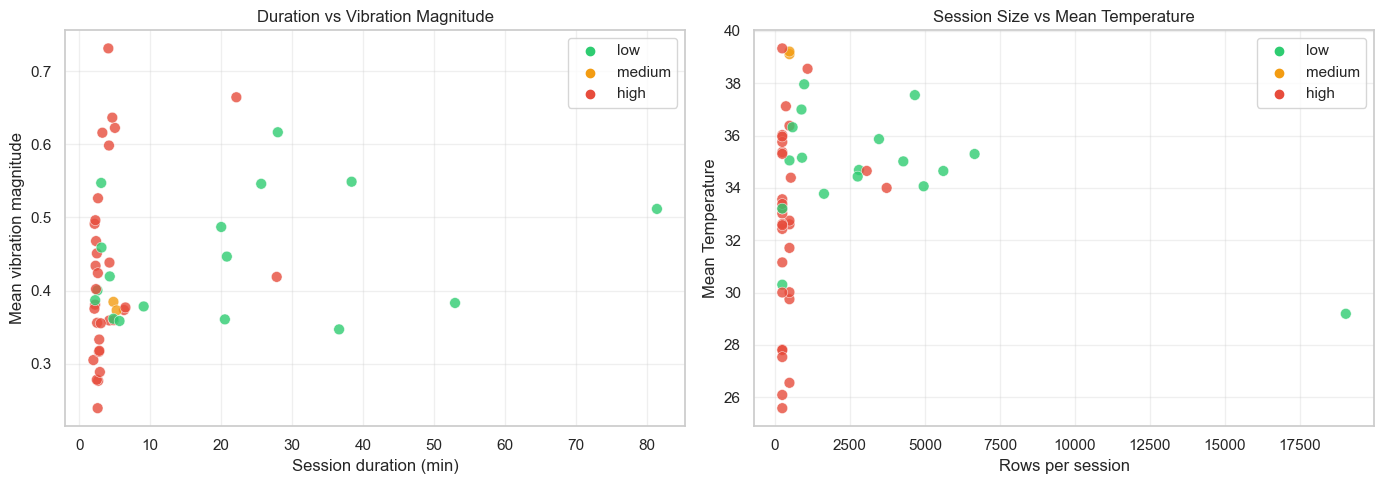

In [85]:
# Scatter: session duration vs mean vibration magnitude
sess_stats['vib_magnitude_mean'] = np.sqrt(
    sess_stats['VibrationX_mean']**2 +
    sess_stats['VibrationY_mean']**2 +
    sess_stats['VibrationZ_mean']**2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [LABEL_COLORS.get(l, 'grey') for l in sess_stats['label']]
axes[0].scatter(sess_stats['duration_min'], sess_stats['vib_magnitude_mean'],
                c=colors, s=60, alpha=0.8, edgecolors='white', linewidth=0.4)
axes[0].set_xlabel('Session duration (min)')
axes[0].set_ylabel('Mean vibration magnitude')
axes[0].set_title('Duration vs Vibration Magnitude')
for label, color in LABEL_COLORS.items():
    axes[0].scatter([], [], color=color, label=label)
axes[0].legend()

axes[1].scatter(sess_stats['n_rows'], sess_stats['Temperature_mean'],
                c=colors, s=60, alpha=0.8, edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Rows per session')
axes[1].set_ylabel('Mean Temperature')
axes[1].set_title('Session Size vs Mean Temperature')
for label, color in LABEL_COLORS.items():
    axes[1].scatter([], [], color=color, label=label)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Vibration Axis Pair Plots

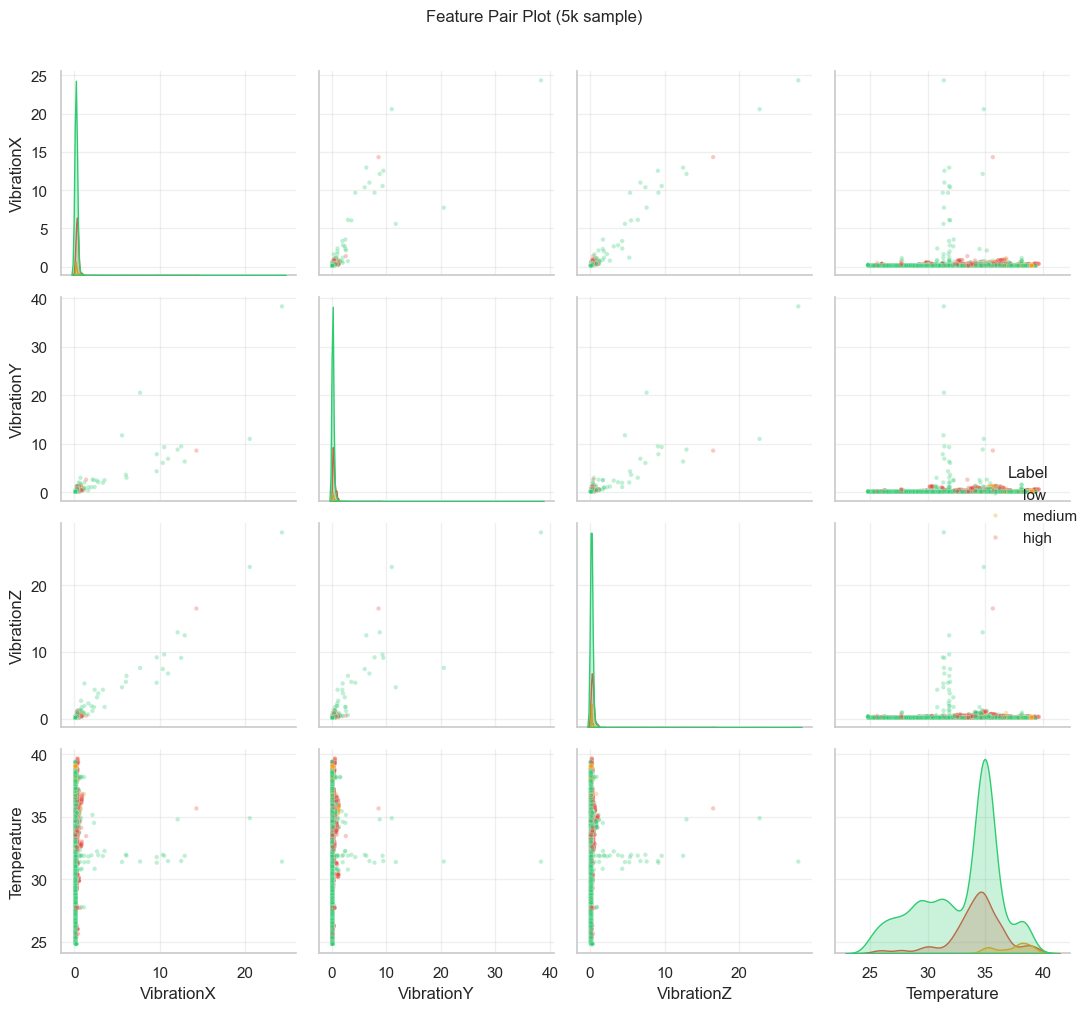

In [86]:
# Sample to keep plot fast
sample = df.sample(n=min(5000, len(df)), random_state=42)

g = sns.pairplot(sample[FEATURES + ['Label']], hue='Label',
                 hue_order=LABEL_ORDER,
                 palette=LABEL_COLORS,
                 diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.fig.suptitle('Feature Pair Plot (5k sample)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 12. Key Findings Summary

| Topic | Finding |
|-------|---------|
| **Sessions** | 51 sessions, highly variable length (240–19,039 rows; 2–81 min) |
| **Sampling rate** | ~500ms within sessions (median interval ≈ 500ms) |
| **Inter-session gaps** | Median ~16 min; max ~58 days — sessions are not continuously recorded |
| **Null values** | 1 null in `Label`; all features complete |
| **Label imbalance** | `low` 74.8%, `high` 22.4%, `medium` 2.8% — severely imbalanced |
| **Vibration axes** | VibrationX, Y, Z are highly correlated (r > 0.9 globally) |
| **Temperature** | Weakly correlated with vibration axes; relatively stable within sessions |
| **Autocorrelation** | All vibration features show strong autocorrelation (lag-1 ≈ 0.99); Temperature slightly lower |
| **Label separability** | Vibration magnitude separates `low` vs `high` reasonably well; `medium` overlaps both |

### Implications for Modelling
- **LSTM windows must respect session boundaries** — inter-session gaps are not predictable intervals.
- **120-row window (60s)** is a reasonable choice: captures enough temporal context without crossing gaps.
- **Class imbalance** (74.8% `low`) warrants class weighting or oversampling for the XGBoost classifier.
- **Vibration axes are redundant** — PCA or feature selection may reduce noise.
- **Temperature** adds orthogonal signal even though it's weakly correlated to vibration.